# 1. Files and Plotting in Python

This notebook introduces two practical skills:

1. reading and writing files;
2. creating simple plots.

## Learning objectives

By the end of this notebook, you should be able to:

- work with file paths;
- read and write text files;
- read and write CSV files;
- use `with open(...)` safely;
- create basic plots with Matplotlib;
- choose a reasonable plot for common data types;
- label plots clearly and save them to disk.

## 1. File paths

A file path tells Python where a file is located.

Python's `pathlib` module is a clean and portable way to work with paths.

In [1]:
from pathlib import Path

current_folder = Path.cwd()
print(current_folder)

data_file = current_folder / "example.txt"
print(data_file)

/Users/fracai/Desktop/mlops/notebooks
/Users/fracai/Desktop/mlops/notebooks/example.txt


In [2]:
# Example using strings

folder = "data"
filename = "patients.csv"

path = folder + "/" + filename

In [3]:
# with pathlib 

from pathlib import Path

folder = Path("data")
path = folder / "patients.csv"

In [4]:
# you can directly do

print(path.exists())
print(path.name)
print(path.suffix)
print(path.parent)

# and to create a folder
folder.mkdir(exist_ok=True)

False
patients.csv
.csv
data


## 2. Writing a text file -- "w"

The safest pattern is to use a context manager:

```python
with open(...) as file:
    ...
```

Python closes the file automatically when the block ends.

In [57]:
from pathlib import Path

file_path = Path("notes.txt")
print(file_path)
print(file_path.parent)
print(file_path.parent.exists())

with open(file_path, "w", encoding="utf-8") as file:
    file.write("Python is readable.\n")
    file.write("Files can be handled with context managers.\n")


print("File written:", file_path)

notes.txt
.
True
File written: notes.txt


In [6]:
# Alternatively, we could open and close a file manually, without context manager

f = open(file_path, "r")
text = f.read()
f.close()

# The problem is that if an error happens before f.close() the file could remain open. Instead, the context manager guarantees that The main advantage is that the cleanup still happens even if an error occurs.

## 3. Reading a text file -- "r"

In [7]:
with open("notes.txt", "r", encoding="utf-8") as file:
    content = file.read()

print(content)

Python is readable.
Files can be handled with context managers.



### Read line by line

In [58]:
with open("notes.txt", "r", encoding="utf-8") as file:
    i = 0
    for line in file:
        print(i)
        print(line.strip())
        i += 1

0
Python is readable.
1
Files can be handled with context managers.


### Creating folders with `pathlib`

The `mkdir()` method creates a new directory.

* `exist_ok=True` prevents an error if the directory already exists.
* `parents=True` also creates any missing parent directories.

This is useful when a script needs to save files into folders that may not exist yet.


In [9]:
from pathlib import Path

folder = Path("results/experiment1/plots")

folder.mkdir(
    parents=True,
    exist_ok=True
)

print(folder)

results/experiment1/plots


Handling missing or invalid files:

In [10]:
try:
    with open("patients.csv", "r", encoding="utf-8") as file:
        print(file.read())

except FileNotFoundError:
    print("File not found.")

name,age,city,diagnosis
Anna,31,Trieste,Hypertension
Marco,42,Milan,Diabetes
Elena,28,Rome,Healthy



## 4. Writing structured data

CSV files are commonly used to exchange tabular data.

The standard library provides the `csv` module.

In [11]:
import csv

rows = [
    ["name", "age", "score"],
    ["Anna", 31, 85],
    ["Marco", 42, 91],
    ["Elena", 28, 88],
]

with open("scores.csv", "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerows(rows) # writes all the rows contained in rows

## 5. Reading CSV data with the standard library

In [12]:
with open("scores.csv", "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    L = []
    for row in reader:
        print(row)
        L.append(row)


['name', 'age', 'score']
['Anna', '31', '85']
['Marco', '42', '91']
['Elena', '28', '88']


Later we will see that **pandas** is usually more convenient for tabular datasets.

In [ ]:
patients = [
    {
        "name": "Anna",
        "age": 31,
        "city": "Trieste",
        "diagnosis": "Hypertension"
    },
    {
        "name": "Marco",
        "age": 42,
        "city": "Milan",
        "diagnosis": "Diabetes"
    },
    {
        "name": "Elena",
        "age": 28,
        "city": "Rome",
        "diagnosis": "Healthy"
    }
]

with open("patients.csv", "w", newline="", encoding="utf-8") as file:

    fieldnames = ["name", "age", "city", "diagnosis"]

    writer = csv.DictWriter(file, fieldnames=fieldnames)

    writer.writeheader() # writes automatically name,age,city,diagnosis (try to comment this out)
    writer.writerows(patients)

In [60]:
# Using DictReader

with open("patients.csv", "r", encoding="utf-8") as file:
    reader = csv.DictReader(file)

    for row in reader:
        print(row)

{'Anna': 'Marco', '31': '42', 'Trieste': 'Milan', 'Hypertension': 'Diabetes'}
{'Anna': 'Elena', '31': '28', 'Trieste': 'Rome', 'Hypertension': 'Healthy'}


In [15]:
# Using general file reader

with open("patients.csv", "r", encoding="utf-8") as file:
    print(file.read())

name,age,city,diagnosis
Anna,31,Trieste,Hypertension
Marco,42,Milan,Diabetes
Elena,28,Rome,Healthy



In [16]:
# You can rebuild a new dictionary while converting the numeric fields:

patients = []

with open("patients.csv", "r", encoding="utf-8") as file:
    reader = csv.DictReader(file)

    for row in reader:
        patient = {
            "name": row["name"],
            "age": int(row["age"]),  ## need to reconvert in the original type (that must be known in advance)
            "city": row["city"],
            "diagnosis": row["diagnosis"]
        }

        patients.append(patient)

print(patients)
patients[0]

[{'name': 'Anna', 'age': 31, 'city': 'Trieste', 'diagnosis': 'Hypertension'}, {'name': 'Marco', 'age': 42, 'city': 'Milan', 'diagnosis': 'Diabetes'}, {'name': 'Elena', 'age': 28, 'city': 'Rome', 'diagnosis': 'Healthy'}]


{'name': 'Anna', 'age': 31, 'city': 'Trieste', 'diagnosis': 'Hypertension'}

# Pickle

CSV files are convenient because they are simple, human-readable, and can be opened by many different programs. However, they store data essentially as text. When we read a CSV file, values such as integers or floating-point numbers may need to be converted back to their original Python types.

Sometimes, instead of saving tabular data for exchange with other tools, we want to save a Python object exactly as it is and load it again later.

For this purpose, Python provides serialization tools such as pickle.

With pickle, objects such as lists, dictionaries, numbers, and more complex Python structures can be saved to a binary file while preserving their structure and data types. When the file is loaded again, the original Python object is reconstructed directly.

This makes pickle convenient for storing Python-specific objects, although unlike CSV, pickle files are not meant to be human-readable or easily exchanged with other software.

In [17]:
import pickle

patients = [
    {"name": "Anna", "age": 31, "city": "Trieste"},
    {"name": "Marco", "age": 42, "city": "Milan"},
]

with open("patients.pkl", "wb") as file:
    pickle.dump(patients, file)

Note: only load pickle files from trusted sources!

In [18]:
with open("patients.pkl", "rb") as file:
    patients_loaded = pickle.load(file)

print(patients_loaded)

[{'name': 'Anna', 'age': 31, 'city': 'Trieste'}, {'name': 'Marco', 'age': 42, 'city': 'Milan'}]


# JSON

In between CSV and pickle because it is structured like Python dictionaries/lists but still human-readable and language-independent.

Try to open the JSON file VS the pickle file!

In [19]:
import json

with open("patients.json", "w", encoding="utf-8") as file:
    json.dump(patients, file, indent=4)

Reading it back:

In [20]:
with open("patients.json", "r", encoding="utf-8") as file:
    patients_loaded = json.load(file)

print(patients_loaded)

[{'name': 'Anna', 'age': 31, 'city': 'Trieste'}, {'name': 'Marco', 'age': 42, 'city': 'Milan'}]


| Format | Human-readable | Preserves Python types | Good for exchange    |
| ------ | -------------- | ---------------------- | -------------------- |
| TXT    | Yes            | No                     | Limited              |
| CSV    | Yes            | Mostly no              | Excellent for tables |
| JSON   | Yes            | Basic types            | Excellent            |
| Pickle | No             | Yes                    | Mostly Python-only   |


# Plotting with Matplotlib

## 6. A first plot

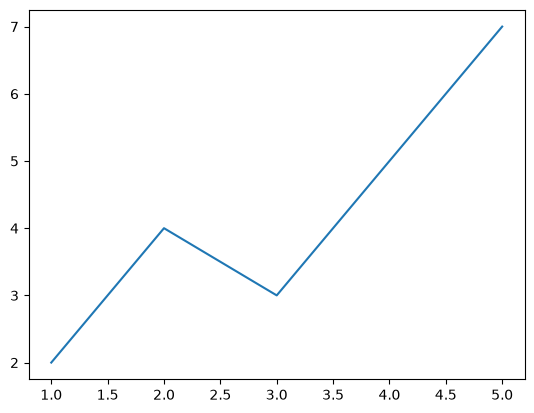

In [21]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [2, 4, 3, 5, 7]

plt.plot(x, y)
plt.show()

A useful plot should normally have:

- a title;
- axis labels;
- meaningful units where appropriate.

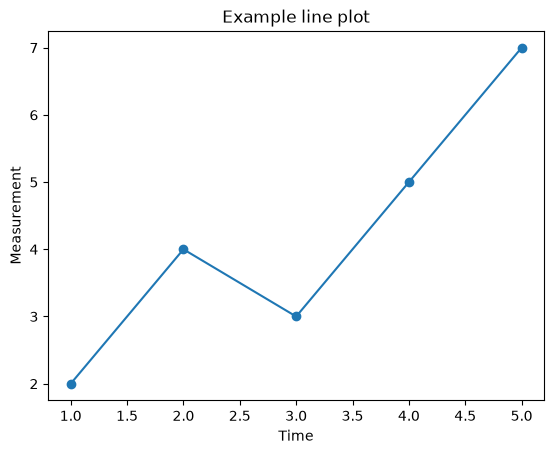

In [22]:
plt.plot(x, y, marker="o")
plt.title("Example line plot")
plt.xlabel("Time") #name axis
plt.ylabel("Measurement")
plt.show()




In [23]:
'''
marker= m=
"o"   # circle
"s"   # square
"^"   # triangle up
"v"   # triangle down
"x"   # x
"+"   # plus
"*"   # star
"."   # point
"D"   # diamond


markersize=10
linewidth=3

linestyle=""
"-"   # solid
"--"  # dashed
"-."  # dash-dot
":"   # dotted


or "o-" means circle markers + line

color =   c=
'r', 'g'
'''

'\nmarker= m=\n"o"   # circle\n"s"   # square\n"^"   # triangle up\n"v"   # triangle down\n"x"   # x\n"+"   # plus\n"*"   # star\n"."   # point\n"D"   # diamond\n\n\nmarkersize=10\nlinewidth=3\n\nlinestyle=""\n"-"   # solid\n"--"  # dashed\n"-."  # dash-dot\n":"   # dotted\n\n\nor "o-" means circle markers + line\n\ncolor =   c=\n\'r\', \'g\'\n'

In [24]:
import numpy as np
import matplotlib.pyplot as plt

x1 = np.linspace(0, 10, 100)
y1 = np.sin(x1)

x2 = np.linspace(0, 100, 100)
y2 = 20 * np.sin(x2 / 10)

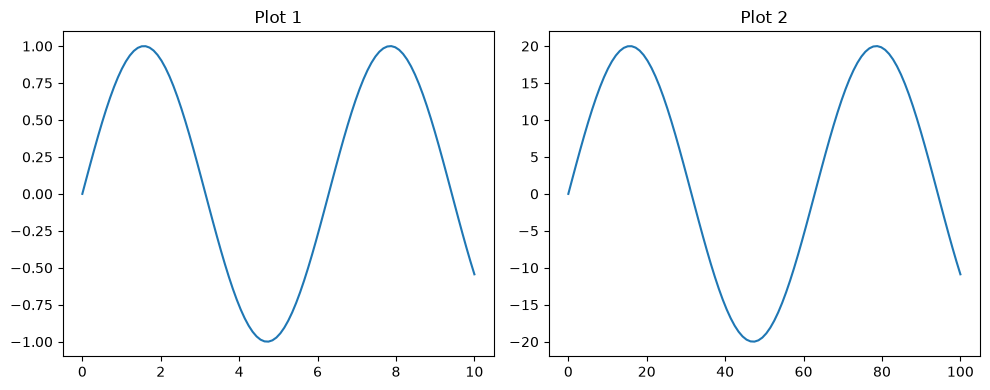

In [25]:
# SEPARATE AXIS
# Here Matplotlib automatically chooses the best limits for each plot independently.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x1, y1)
axes[0].set_title("Plot 1")

axes[1].plot(x2, y2)
axes[1].set_title("Plot 2")

plt.tight_layout()
plt.show()

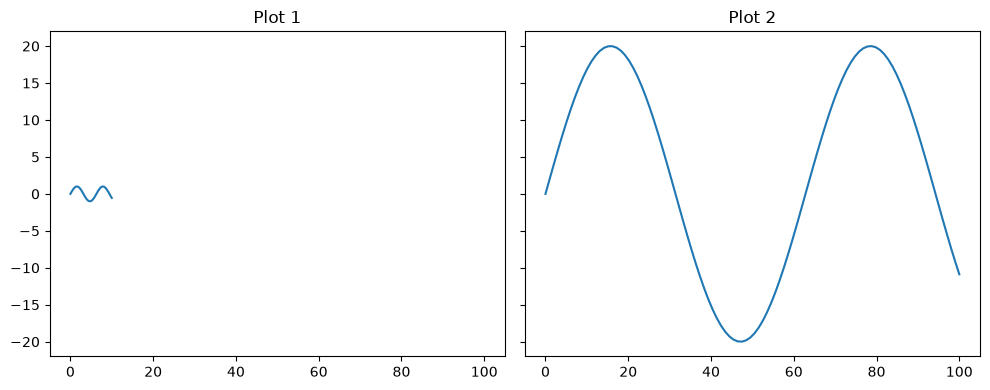

In [26]:
# COMMON X and Y AXIS
# Now both plots use the same x and y scale.

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4),
    sharex=True,
    sharey=True
)

axes[0].plot(x1, y1)
axes[0].set_title("Plot 1")

axes[1].plot(x2, y2)
axes[1].set_title("Plot 2")

plt.tight_layout()
plt.show()

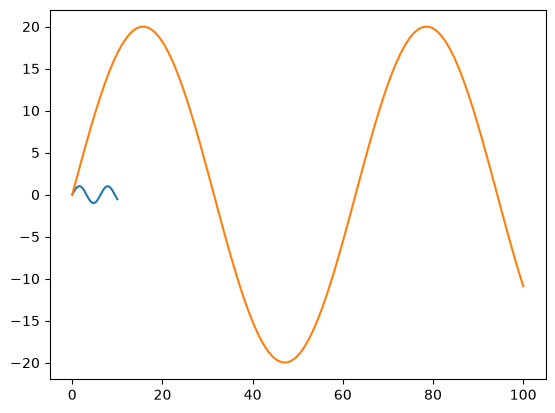

In [27]:
plt.plot(x1,y1)
plt.plot(x2,y2)
plt.show()

# Annotations

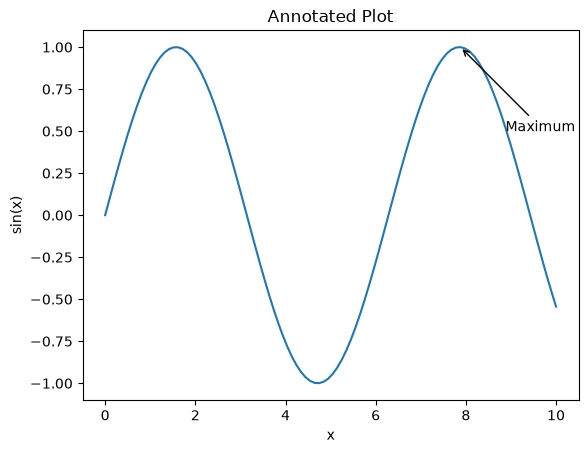

In [28]:
# Data
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Find the maximum value
y_max = np.max(y)

# Find the x corresponding to the maximum
x_max = x[np.argmax(y)]

# Plot
plt.plot(x, y)

# Add annotation
plt.annotate(
    "Maximum",
    xy=(x_max, y_max),              # point to annotate
    xytext=(x_max + 1, y_max - 0.5), # position of the text
    arrowprops={"arrowstyle": "->"}
)

plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Annotated Plot")

plt.show()

## 7. Scatter plots

Scatter plots are useful for studying the relationship between two numerical variables.

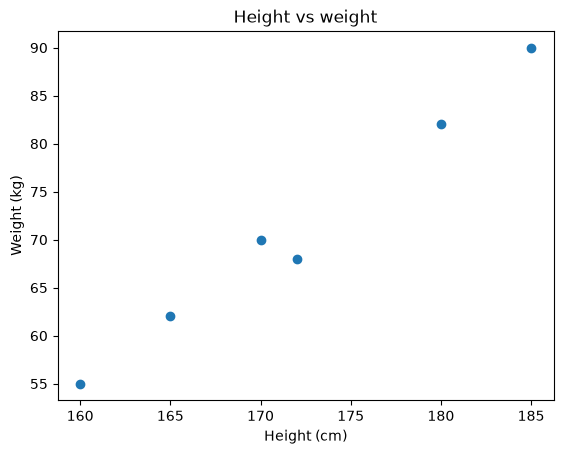

In [29]:
heights = [160, 165, 170, 172, 180, 185]
weights = [55, 62, 70, 68, 82, 90]

plt.scatter(heights, weights)
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs weight")
plt.show()

## 8. Bar plots

Bar plots are useful for comparing categories.

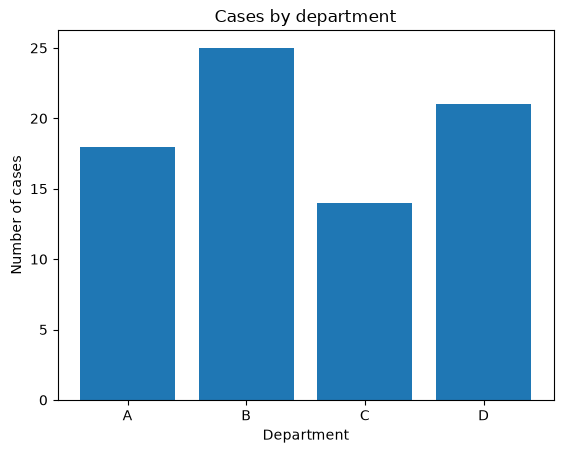

In [30]:
departments = ["A", "B", "C", "D"]
counts = [18, 25, 14, 21]

plt.bar(departments, counts)
plt.xlabel("Department")
plt.ylabel("Number of cases")
plt.title("Cases by department")
plt.show()

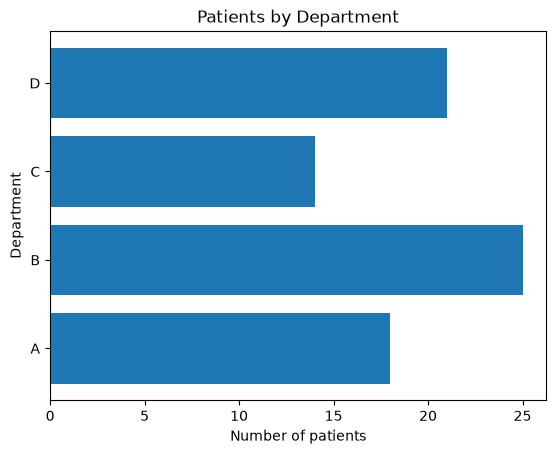

In [31]:
# Horizontal

plt.barh(departments, counts)
plt.xlabel("Number of patients")
plt.ylabel("Department")
plt.title("Patients by Department")
plt.show()

You can also compare two groups side by side:

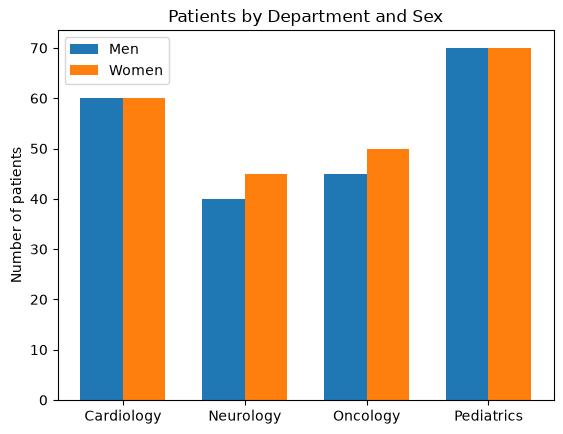

In [32]:
import numpy as np
departments = ["Cardiology", "Neurology", "Oncology", "Pediatrics"]

men = [60, 40, 45, 70]
women = [60, 45, 50, 70]

x = np.arange(len(departments))
width = 0.35

plt.bar(x - width/2, men, width, label="Men")
plt.bar(x + width/2, women, width, label="Women")

plt.xticks(x, departments)
plt.ylabel("Number of patients")
plt.title("Patients by Department and Sex")
plt.legend()

plt.show()

## 9. Histograms

Histograms show the distribution of a numerical variable.

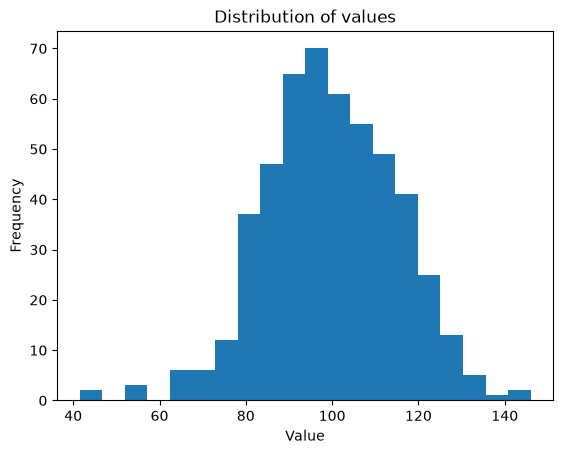

In [33]:
import numpy as np

rng = np.random.default_rng(0)
values = rng.normal(loc=100, scale=15, size=500)

plt.hist(values, bins=20)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of values")
plt.show()

# Box-plots

Useful for showing the distribution of a numerical variable and comparing groups.

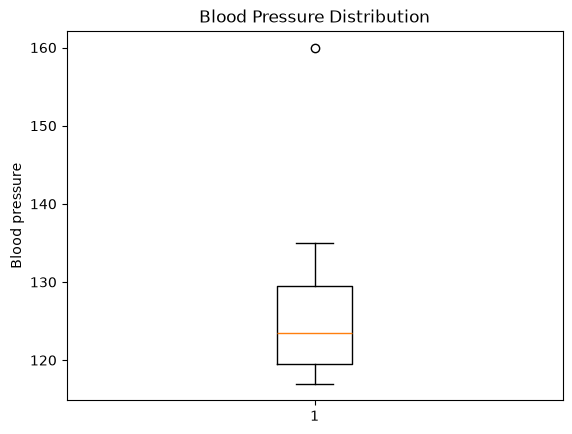

In [34]:
blood_pressure = [118, 122, 130, 125, 119, 135, 128, 121, 117, 160]

plt.boxplot(blood_pressure)
plt.ylabel("Blood pressure")
plt.title("Blood Pressure Distribution")
plt.show()

A box plot summarizes:

- the median
- the first quartile (Q1)
- the third quartile (Q3)
- the interquartile range, \(IQR = Q3 - Q1\)
- the whiskers
possible outliers

For comparing groups:

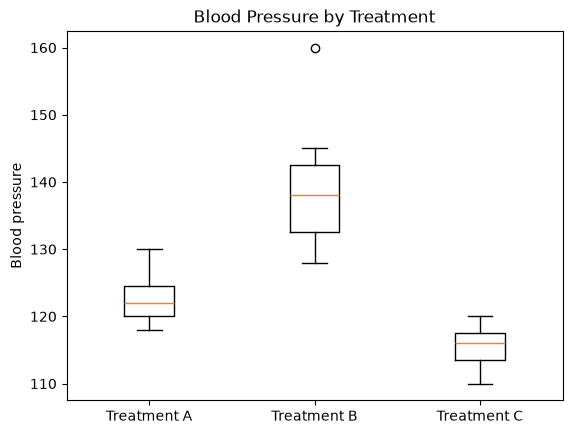

In [35]:
group_a = [118, 122, 125, 121, 119, 130, 124]
group_b = [130, 135, 128, 140, 145, 138, 160]
group_c = [110, 115, 118, 112, 117, 120, 116]

plt.boxplot(
    [group_a, group_b, group_c],
    tick_labels=["Treatment A", "Treatment B", "Treatment C"]
)

plt.ylabel("Blood pressure")
plt.title("Blood Pressure by Treatment")
plt.show()

Medical example where you can immediately compare central tendency, variability, and outliers across treatments.

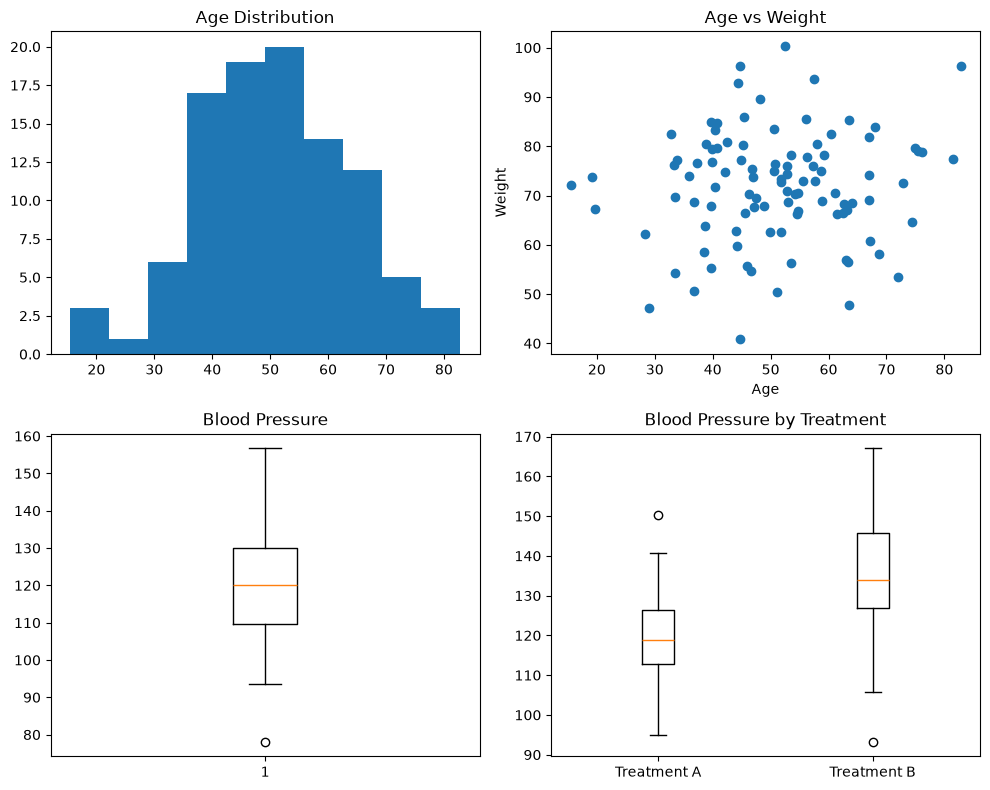

In [36]:

np.random.seed(1)

age = np.random.normal(50, 15, 100)
weight = np.random.normal(70, 12, 100)
blood_pressure = np.random.normal(120, 15, 100)

group_a = np.random.normal(120, 10, 50)
group_b = np.random.normal(135, 15, 50)

fig, axes = plt.subplots(2, 2, figsize=(10, 8)) # GRID OF PLOTS

axes[0, 0].hist(age)
axes[0, 0].set_title("Age Distribution")

axes[0, 1].scatter(age, weight)
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Weight")
axes[0, 1].set_title("Age vs Weight")

axes[1, 0].boxplot(blood_pressure)
axes[1, 0].set_title("Blood Pressure")

axes[1, 1].boxplot(
    [group_a, group_b],
    tick_labels=["Treatment A", "Treatment B"]
)
axes[1, 1].set_title("Blood Pressure by Treatment")

plt.tight_layout()
plt.show()

# Errorbars

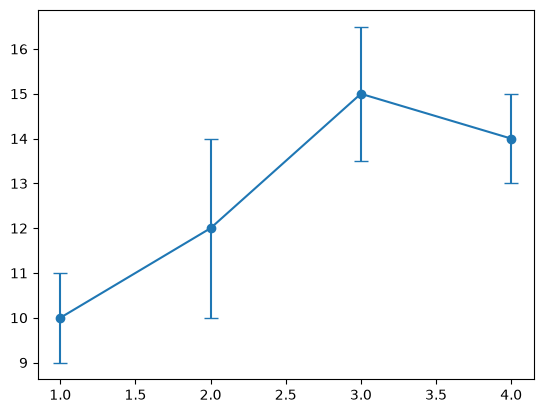

In [37]:
x = [1, 2, 3, 4]
mean = [10, 12, 15, 14]
std = [1, 2, 1.5, 1]

plt.errorbar(x, mean, yerr=std, marker="o", capsize=5)
plt.show()

# Confidence intervals

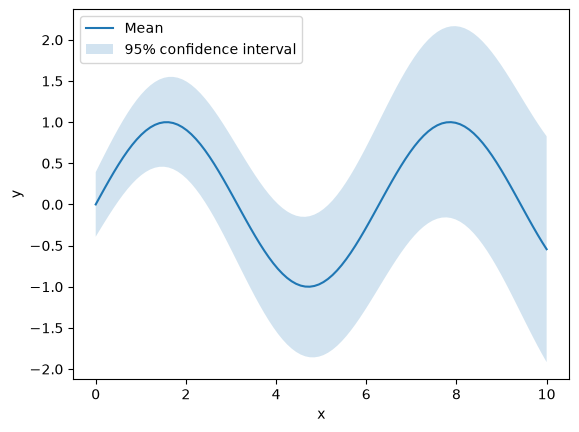

In [38]:
x = np.linspace(0, 10, 100)

mean = np.sin(x)
std = 0.2 + 0.05 * x

lower = mean - 1.96 * std
upper = mean + 1.96 * std

plt.plot(x, mean, label="Mean")

plt.fill_between(
    x,
    lower,
    upper,
    alpha=0.2,
    label="95% confidence interval"
)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

One small statistical caveat: mean ± 1.96 * std is not generally a confidence interval for the mean. If std is the sample standard deviation, a rough large-sample 95% CI would instead use:

In [39]:
n_samples = 1000
lower = mean - 1.96 * std / np.sqrt(n_samples)
upper = mean + 1.96 * std / np.sqrt(n_samples)

## 10. Multiple series

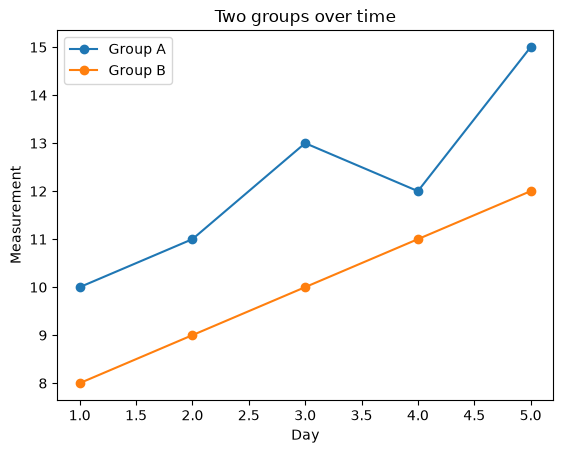

In [40]:
days = [1, 2, 3, 4, 5]
series_a = [10, 11, 13, 12, 15]
series_b = [8, 9, 10, 11, 12]

plt.plot(days, series_a, marker="o", label="Group A")
plt.plot(days, series_b, marker="o", label="Group B")
plt.xlabel("Day")
plt.ylabel("Measurement")
plt.title("Two groups over time")
plt.legend()                                                ## LEGEND
plt.show()

## 11. Saving a figure

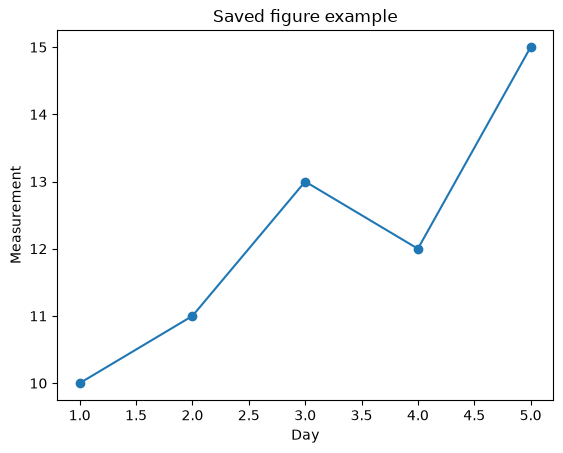

In [41]:
plt.plot(days, series_a, marker="o")
plt.title("Saved figure example")
plt.xlabel("Day")
plt.ylabel("Measurement")

plt.savefig("example_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Choosing a plot

A rough rule of thumb:

| Goal | Plot |
|---|---|
| Numerical distribution | histogram |
| Compare categories | bar plot |
| Relationship between two numerical variables | scatter plot |
| Evolution over ordered values/time | line plot |
| Distribution across groups | box plot |

# Heatmap

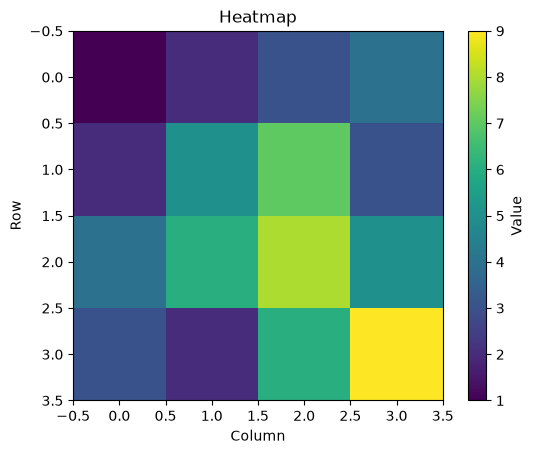

In [42]:
data = [
    [1, 2, 3, 4],
    [2, 5, 7, 3],
    [4, 6, 8, 5],
    [3, 2, 6, 9]
]

plt.imshow(data)
plt.colorbar(label="Value")
plt.title("Heatmap")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()

You can also display the values inside the cells:

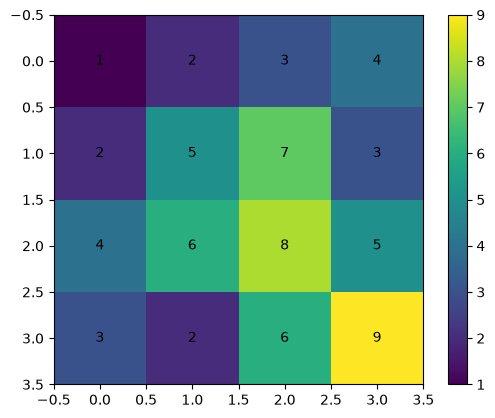

In [43]:
plt.imshow(data)
plt.colorbar()

for i in range(len(data)):
    for j in range(len(data[0])):
        plt.text(j, i, data[i][j], ha="center", va="center")

plt.show()

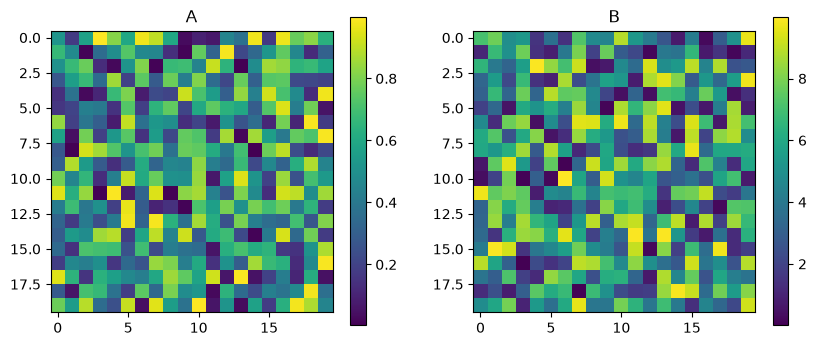

In [44]:
## SEPARATE COLORBARS

import numpy as np
import matplotlib.pyplot as plt

A = np.random.rand(20, 20)          # values roughly between 0 and 1
B = 10 * np.random.rand(20, 20)     # values roughly between 0 and 10

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im1 = axes[0].imshow(A)
im2 = axes[1].imshow(B)

axes[0].set_title("A")
axes[1].set_title("B")

fig.colorbar(im1, ax=axes[0])
fig.colorbar(im2, ax=axes[1])

plt.show()

The issue is that the same color does not represent the same value in the two plots. A bright region in A may correspond to about 1, while a bright region in B may correspond to about 10.plt.show()


# Common color scale and common colorbar

Now both plots use the same normalization:

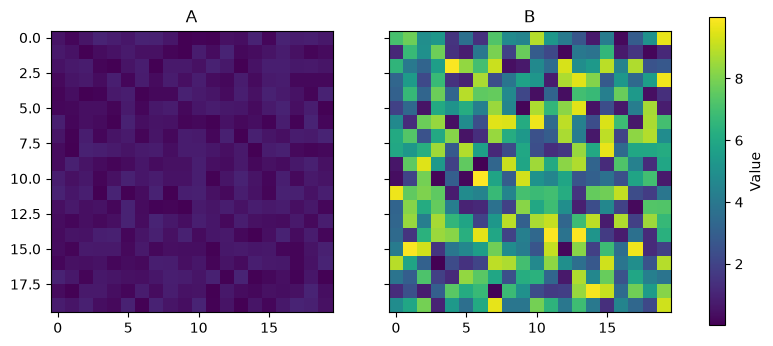

In [45]:
vmin = min(A.min(), B.min())
vmax = max(A.max(), B.max())

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4),
    sharex=True,
    sharey=True
)

im1 = axes[0].imshow(A, vmin=vmin, vmax=vmax)
im2 = axes[1].imshow(B, vmin=vmin, vmax=vmax)

axes[0].set_title("A")
axes[1].set_title("B")

fig.colorbar(im1, ax=axes, label="Value")


# Contour plot

Useful to visualize a function of two variables:

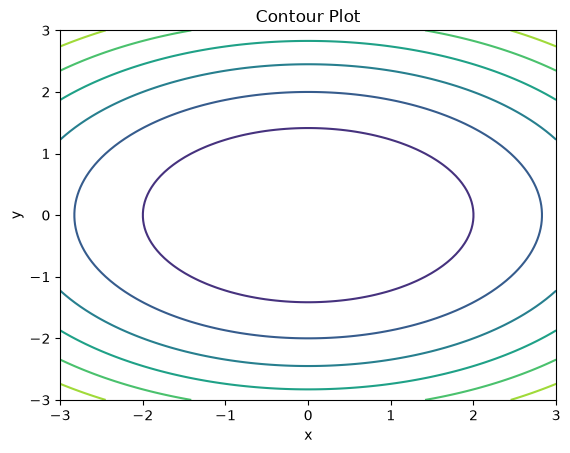

In [46]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)

X, Y = np.meshgrid(x, y)

Z = 2 * X**2 + 4 * Y**2

plt.contour(X, Y, Z)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Contour Plot")
plt.show()

In [47]:
## meshgrid
print("Xmesh = ", X, X.shape)
print("Ymesh = ", Y, Y.shape)

Xmesh =  [[-3.         -2.93939394 -2.87878788 ...  2.87878788  2.93939394
   3.        ]
 [-3.         -2.93939394 -2.87878788 ...  2.87878788  2.93939394
   3.        ]
 [-3.         -2.93939394 -2.87878788 ...  2.87878788  2.93939394
   3.        ]
 ...
 [-3.         -2.93939394 -2.87878788 ...  2.87878788  2.93939394
   3.        ]
 [-3.         -2.93939394 -2.87878788 ...  2.87878788  2.93939394
   3.        ]
 [-3.         -2.93939394 -2.87878788 ...  2.87878788  2.93939394
   3.        ]] (100, 100)
Ymesh =  [[-3.         -3.         -3.         ... -3.         -3.
  -3.        ]
 [-2.93939394 -2.93939394 -2.93939394 ... -2.93939394 -2.93939394
  -2.93939394]
 [-2.87878788 -2.87878788 -2.87878788 ... -2.87878788 -2.87878788
  -2.87878788]
 ...
 [ 2.87878788  2.87878788  2.87878788 ...  2.87878788  2.87878788
   2.87878788]
 [ 2.93939394  2.93939394  2.93939394 ...  2.93939394  2.93939394
   2.93939394]
 [ 3.          3.          3.         ...  3.          3.
   3.        ]] (10

Or filled contours:

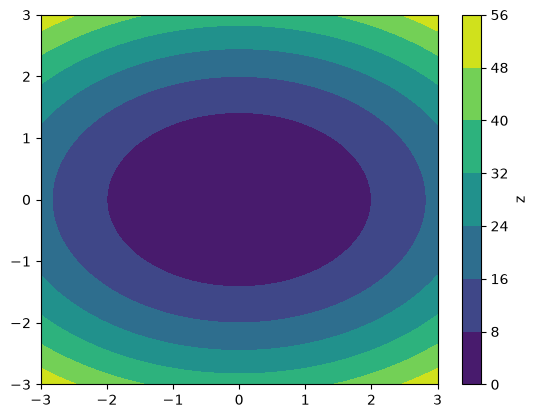

In [48]:
plt.contourf(X, Y, Z)
plt.colorbar(label="z")
plt.show()

# 3D surface

The same function can be shown as a surface:

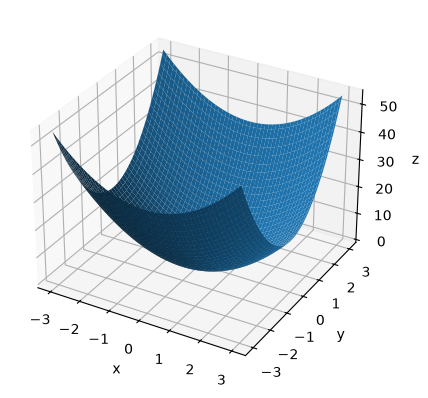

In [49]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

A more interesting surface:

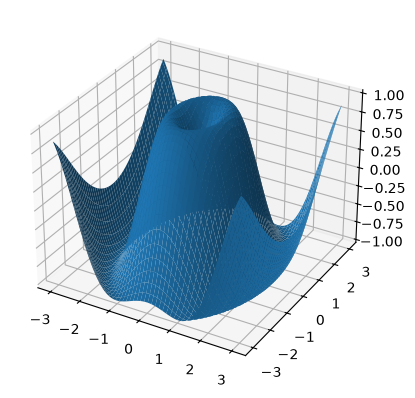

In [50]:
Z = np.sin(np.sqrt(4*X**2 + 2*Y**2))

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z)

plt.show()

# 3D scatter plot

Useful when you have three measured variables:

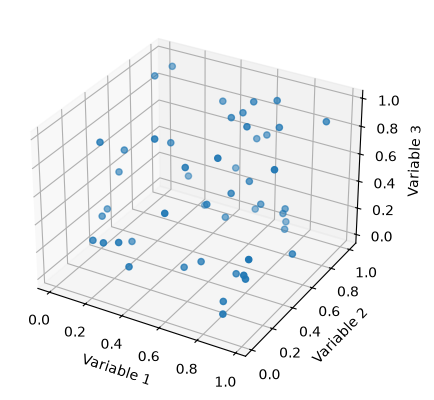

In [51]:
x = np.random.rand(50)
y = np.random.rand(50)
z = np.random.rand(50)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z)

ax.set_xlabel("Variable 1")
ax.set_ylabel("Variable 2")
ax.set_zlabel("Variable 3")

plt.show()

# Bubble plot

You can use the size of the marker to represent a fourth variable:

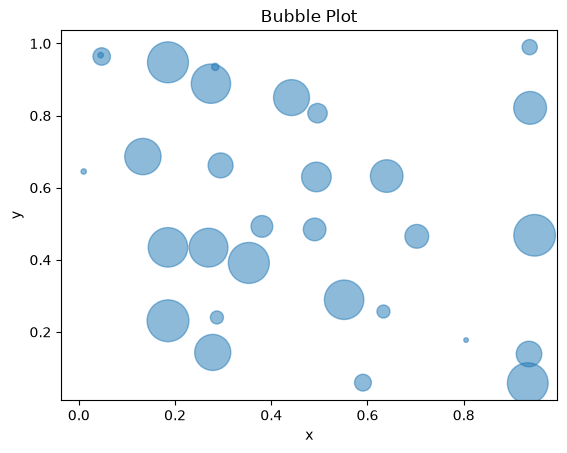

In [52]:
x = np.random.rand(30)
y = np.random.rand(30)
size = np.random.rand(30) * 1000

plt.scatter(x, y, s=size, alpha=0.5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Bubble Plot")

plt.show()

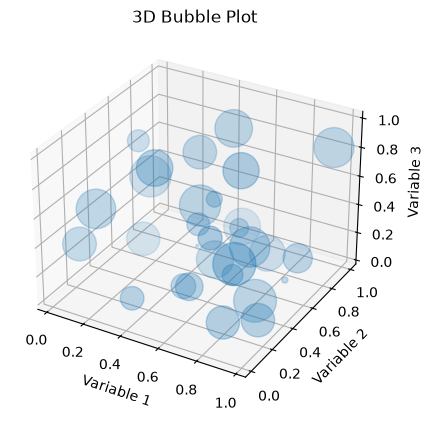

In [53]:
# Example data
np.random.seed(0)

x = np.random.rand(30)
y = np.random.rand(30)
z = np.random.rand(30)

# Fourth variable: controls bubble size
size = np.random.rand(30) * 1000

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, s=size, alpha=0.6)

ax.set_xlabel("Variable 1")
ax.set_ylabel("Variable 2")
ax.set_zlabel("Variable 3")
ax.set_title("3D Bubble Plot")

plt.show()

# Vector field

This is a bit more advanced and useful in physics, dynamical systems, or differential equations:

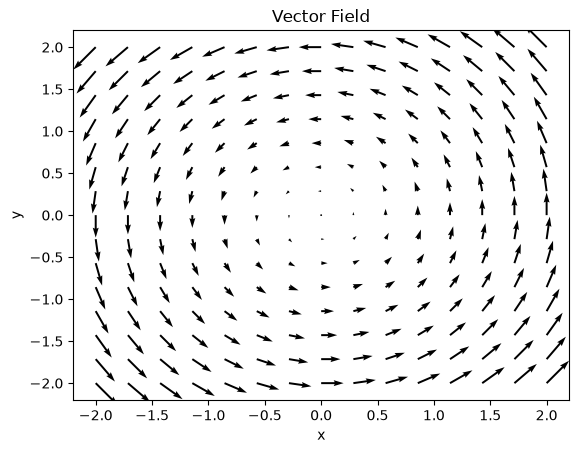

In [54]:
x = np.linspace(-2, 2, 15)
y = np.linspace(-2, 2, 15)

X, Y = np.meshgrid(x, y)

U = -Y
V = X

plt.quiver(X, Y, U, V)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Vector Field")

plt.show()

# Exercise

Create a file called `temperatures.txt` containing five temperature values, one per line.

Then:

1. read the values;
2. convert them to floats;
3. plot them as a line plot;
4. add labels and a title;
5. save the figure.

In [55]:
# Write your solution here

# Possible solution

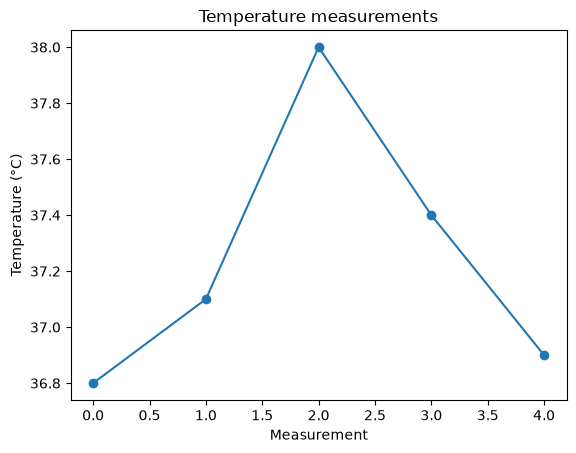

In [56]:
temperatures = [36.8, 37.1, 38.0, 37.4, 36.9]

with open("temperatures.txt", "w", encoding="utf-8") as file:
    for temperature in temperatures:
        file.write(f"{temperature}\n")

loaded_temperatures = []

with open("temperatures.txt", "r", encoding="utf-8") as file:
    for line in file:
        loaded_temperatures.append(float(line.strip()))

plt.plot(loaded_temperatures, marker="o")
plt.xlabel("Measurement")
plt.ylabel("Temperature (°C)")
plt.title("Temperature measurements")
plt.savefig("temperatures.png", dpi=150, bbox_inches="tight")
plt.show()

# Take-home messages

- `pathlib` is a convenient way to handle file paths.
- Use `with open(...)` when reading and writing files.
- CSV is a common format for structured tabular data.
- Matplotlib provides the basic plotting API in Python.
- Always label plots clearly.
- The plot type should match the question you are trying to answer.